<a href="https://colab.research.google.com/github/KishoreKumar477/ml-supervised/blob/main/ccfraudprediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [153]:
import kagglehub
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")


Using Colab cache for faster access to the 'creditcardfraud' dataset.


In [154]:
import pandas as pd
import os

csv_file_path = os.path.join(path, 'creditcard.csv')
df=pd.read_csv(csv_file_path)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [155]:
df.shape
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## Target Variable Distribution




**Reasoning**:
To understand the distribution of the 'Class' column, I need to calculate the value counts for each class (fraudulent and non-fraudulent) and then visualize them using a count plot with appropriate labels, title, and a legend.



Distribution of 'Class' column:
 Class
0    284315
1       492
Name: count, dtype: int64


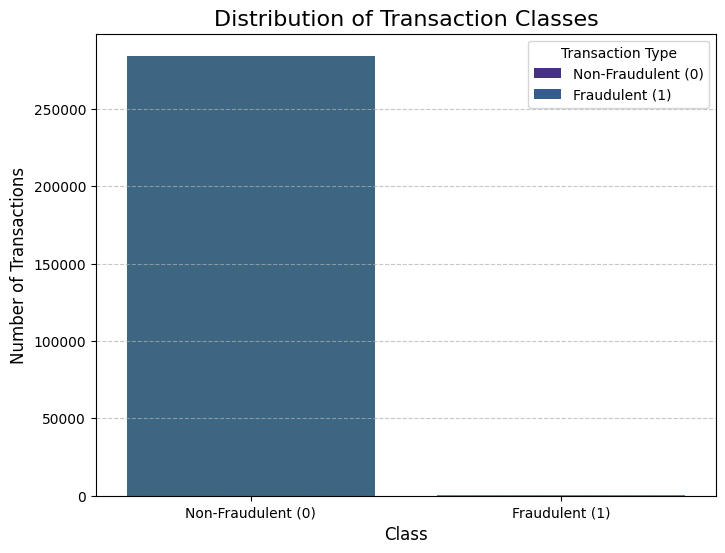

In [156]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the value counts of the 'Class' column
class_distribution = df['Class'].value_counts()

print("Distribution of 'Class' column:\n", class_distribution)

# Create a count plot to visualize the distribution
plt.figure(figsize=(8, 6))
sns.barplot(x=class_distribution.index, y=class_distribution.values, hue=class_distribution.index, palette='viridis', legend=False)

# Labeling the plot
plt.title('Distribution of Transaction Classes', fontsize=16)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)

# Customize x-axis ticks for better readability and add legend
plt.xticks(ticks=[0, 1], labels=['Non-Fraudulent (0)', 'Fraudulent (1)'], fontsize=10)

# Create a dummy legend to explain the classes since seaborn barplot doesn't auto-generate legend for single categorical column like this.
# We can add text annotations or a custom legend to explain the meaning of 0 and 1.
# For a more explicit legend, we can create custom artists.
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=sns.color_palette('viridis')[0], label='Non-Fraudulent (0)'),
                   Patch(facecolor=sns.color_palette('viridis')[1], label='Fraudulent (1)')]
plt.legend(handles=legend_elements, title='Transaction Type', loc='upper right')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Missing Values Analysis



**Reasoning**:
To check for missing values, I will calculate the sum of null values for each column and display them. If missing values exist, I will create a heatmap to visualize their distribution across the dataset.



In [157]:
missing_values = df.isnull().sum()

# Filter to show only columns with missing values
missing_values = missing_values[missing_values > 0]

print("Columns with missing values and their counts:")
if missing_values.empty:
    print("No missing values found in the dataset.")
else:
    print(missing_values)

    # Visualize missing values if any are found
    import matplotlib.pyplot as plt
    import seaborn as sns

    plt.figure(figsize=(12, 6))
    sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
    plt.title('Missing Values Heatmap')
    plt.show()


Columns with missing values and their counts:
No missing values found in the dataset.


##standardscalar


In [158]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
df['Amount']=sc.fit_transform(pd.DataFrame(df['Amount']))

In [159]:
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244964,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342475,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.160686,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.140534,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073403,0


In [160]:
df=df.drop_duplicates()

In [161]:
df.shape


(283726, 31)

In [162]:
df.drop(['Time'],axis=1, inplace=True)

## Descriptive Statistics


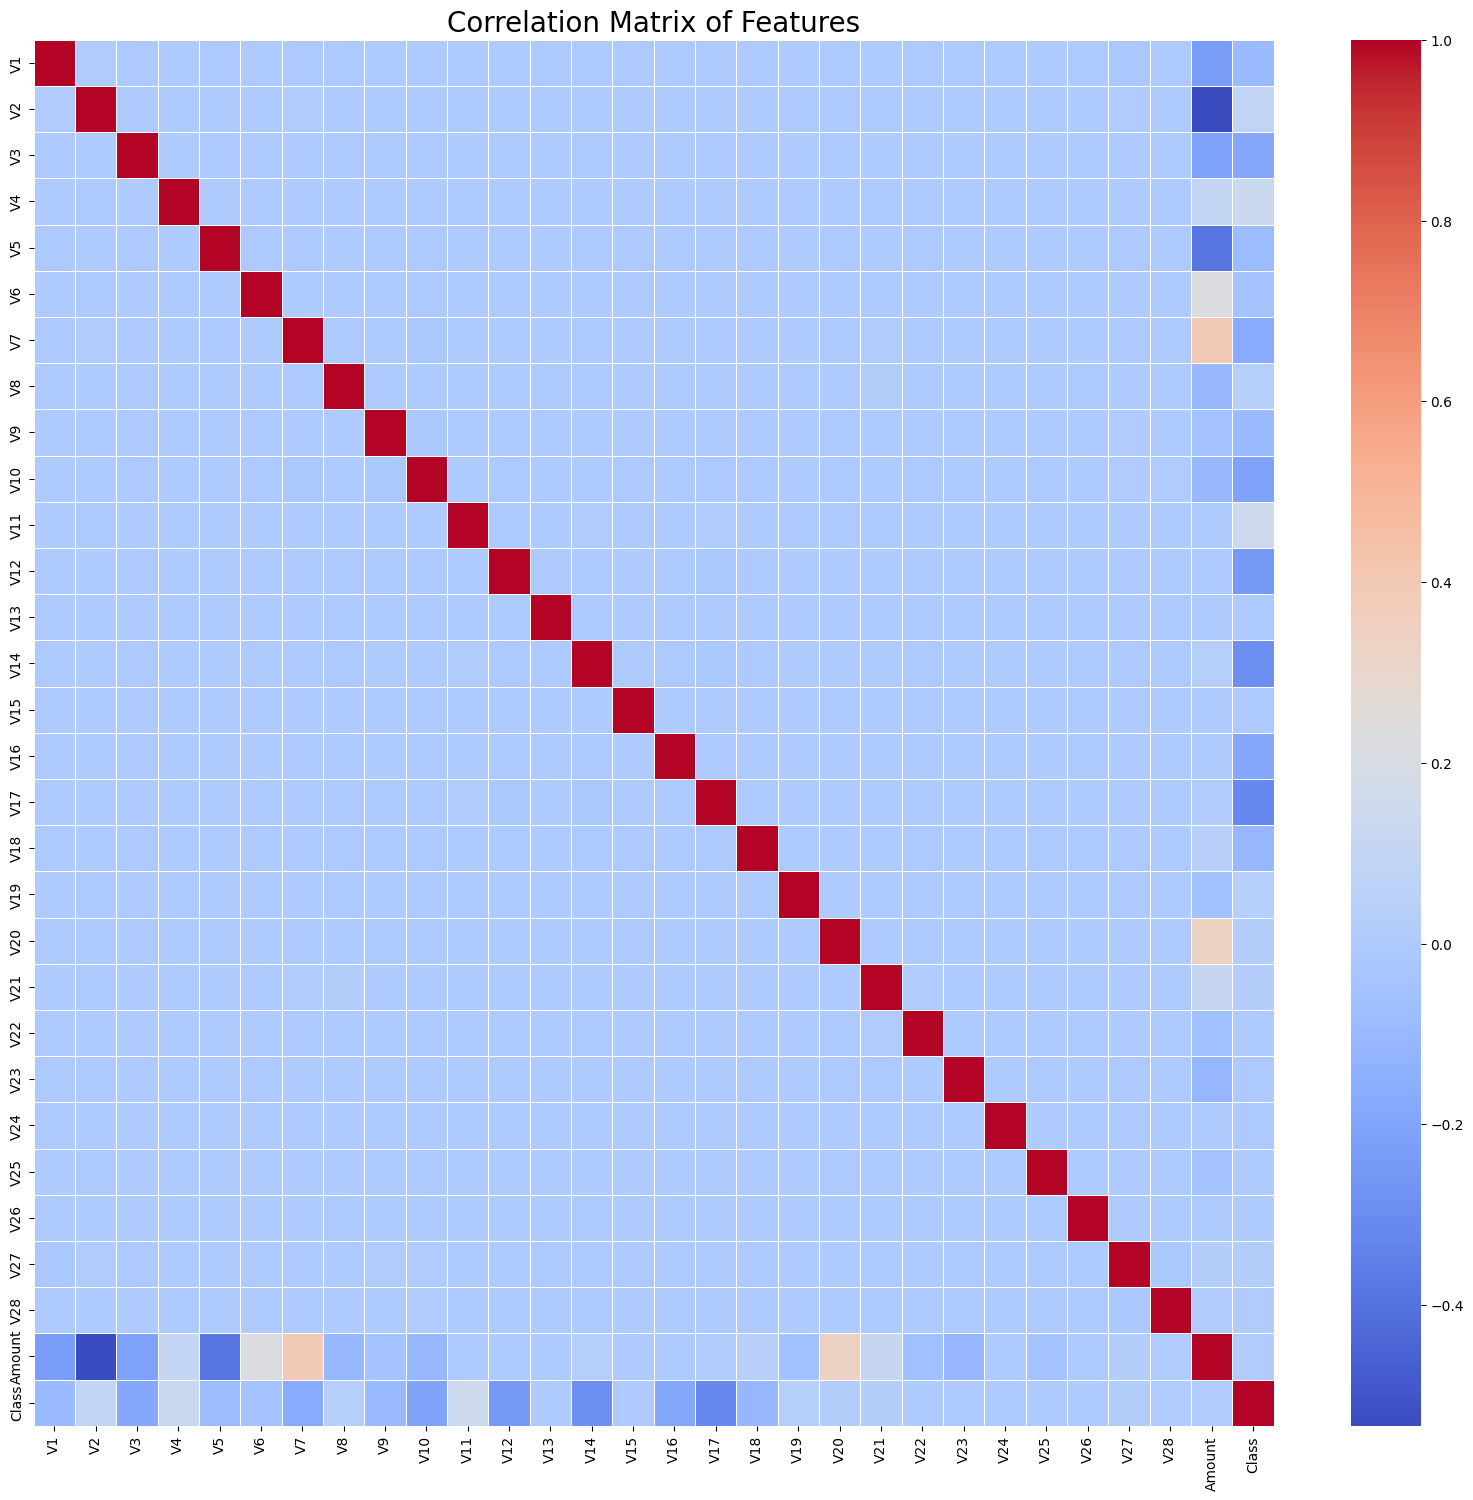

In [163]:
import matplotlib.pyplot as plt
import seaborn as sns

correlation_matrix = df.corr()

plt.figure(figsize=(20, 18))

sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5, cbar=True)

plt.title('Correlation Matrix of Features', fontsize=20)

plt.show()

In [164]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


[0.00476489 0.00512631 0.00266206 ... 0.00165238 0.05094178 0.02269183]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.84      0.76      0.80        90

    accuracy                           1.00     56746
   macro avg       0.92      0.88      0.90     56746
weighted avg       1.00      1.00      1.00     56746



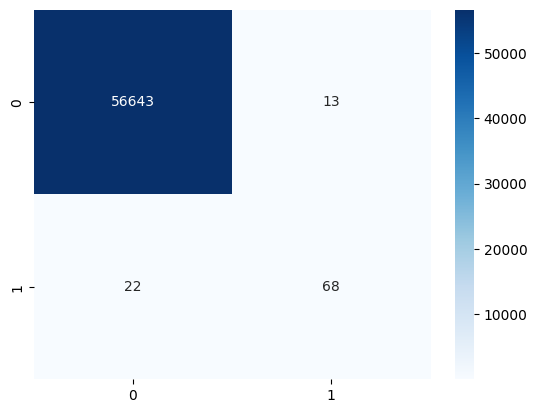

In [168]:
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# We use a 1:10 ratio (0.1) instead of 1:1.
# This tells the model fraud is rare, which fixes your "0.06 Precision" problem.
model_pipeline = Pipeline([
    ('resample', RandomUnderSampler(sampling_strategy=0.1, random_state=42)),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=12, n_jobs=-1, random_state=42))
])

# (It automatically handles the undersampling only on the training data)
model_pipeline.fit(X_train, y_train)

# Instead of a hard 0 or 1, we get the likelihood of fraud
y_probs = model_pipeline.predict_proba(X_test)[:, 1]
print(y_probs)

#Apply a custom threshold
# Let's be 80% sure before we block a card
threshold = 0.8
y_pred_custom = (y_probs >= threshold).astype(int)

#Evaluate
print(classification_report(y_test, y_pred_custom))
sns.heatmap(confusion_matrix(y_test, y_pred_custom), annot=True, fmt='d', cmap='Blues')
plt.show()

In [166]:
print(y_pred_custom.shape
)

(56746,)


#Feature Importance

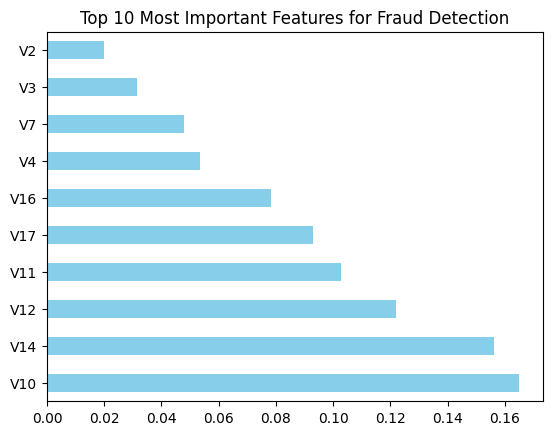

In [167]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract the classifier from the pipeline
rf_model = model_pipeline.named_steps['classifier']

# Get feature names (assuming X_train is a DataFrame)
feature_names = X_train.columns
importances = rf_model.feature_importances_

feat_importances = pd.Series(importances, index=feature_names)
#top 10 feature
feat_importances.nlargest(10).plot(kind='barh', color='skyblue')
plt.title("Top 10 Most Important Features for Fraud Detection")
plt.show()